In [1]:
import logging
# Let's disable all the annoying messages from PySME
logging.disable(logging.WARNING)
import warnings
warnings.filterwarnings(action="ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", module="pysme.synthesize")
# from astropy.utils.exceptions import AstropyWarning
# warnings.filterwarnings(action="ignore", category=AstropyWarning)
import numpy as np
import matplotlib.pyplot as plt
%matplotlib widget
np.set_printoptions(suppress=True, precision=6)

In [ ]:
%load_ext autoreload
%autoreload 2
from pysme_wrapper.utils import *
from pysme_wrapper.core import *

/home/paramre/miniforge3/envs/sme/lib/python3.12/site-packages/pysynphot/locations.py:46: UserWarning: PYSYN_CDBS is undefined; functionality will be SEVERELY crippled.
  warnings.warn("PYSYN_CDBS is undefined; functionality will be SEVERELY "
/home/paramre/miniforge3/envs/sme/lib/python3.12/site-packages/pysynphot/locations.py:345: UserWarning: Extinction files not found in extinction
  warnings.warn('Extinction files not found in %s' % (extdir, ))


In [ ]:
class FEROSspec:
    def __init__(self, filepath):
        with fits.open(filepath) as hdul:
            self.header = hdul[0].header
            self.wave_echelle = hdul[1].data
            self.wavelength = hdul[12].data
            self.flux = hdul[15].data
            self.getR = self.create_global_R_interpolant()

    def create_global_R_interpolant(self):  
        from scipy.interpolate import interp1d
        gridres=0.03
        waveord = self.wave_echelle
        # Create a fine grid spanning the global wavelength range.
        wave_grid = np.arange(waveord.min(), waveord.max()+gridres, gridres)
        Rgrid = np.zeros([len(waveord),len(wave_grid)])
        
        # Evaluate R at each grid point from each order
        for i, wave in enumerate(waveord):
            # Create interpolator; points outside the range return NaN.
            R = np.zeros(len(wave)); R[1:] = wave[1:]/(np.diff(wave)*2.2); R[0] = R[1]
            Rgrid[i] = np.interp(wave_grid, wave, R, left=np.nan, right=np.nan)
        
        #  Combine them    
        Ngp = np.isfinite(Rgrid).sum(0)
        c1 = Ngp==1
        c2 = Ngp==2
        c3 = Ngp>2
        Rcomb = np.zeros(len(wave_grid))
        Rcomb[c1|c3] = np.nanmedian(Rgrid[:,c1|c3], axis=0)
        Rcomb[c2] = np.nanmin(Rgrid[:,c2], axis=0)
        
        # Create a global interpolant object from the computed grid.
        global_R_interpolant = interp1d(wave_grid, Rcomb, kind='linear', bounds_error=True)
        return global_R_interpolant  

In [ ]:
# load example spectrum
spec = FEROSspec('tauCeti_FEROS_spectrum_20250118.fits')
# some cleanup
spec.flux[(spec.wavelength<4500)&(spec.flux>1.05)] = np.nan
spec.flux[(spec.wavelength>4500)&(spec.flux>1.02)] = np.nan

In [ ]:
plt.figure(figsize=(15,6))
plt.plot(spec.wavelength, spec.flux)
plt.axhline(1.02, color='k', ls=':')
plt.axhline(1.05, color='k', ls=':')
plt.tight_layout()

In [ ]:
plt.figure(figsize=(10,3))
plt.plot(spec.wavelength, spec.getR(spec.wavelength))
plt.tight_layout()

## Typical workflow for for fitting stellar parameters and [Fe/H] using SMEwrapper

### Create SMEwrapper object and input observed spectrum

If you have any preferred/seed stellar parameters, you can input them here. Otherwise, the default (Solar) will suffice for an FGK star.

In [ ]:
sme = SMEwrapper(teff=5250, logg=4.5, vsini=5.5)

In [ ]:
# Input your observed spectrum
sme.input_observed_spectrum(wave=spec.wavelength, flux=spec.flux, res=spec.getR(spec.wavelength)) 

You can also build the approximate telluric transmission spectrum for your observation. The paramters needed are generally given in the primary header of the spectrum fits file.

- Note particularly the `nan_thresh` argument - this will set the observed flux to NaN for points where the telluric transmission is below the threshold. This is the easiest way to account for telluric contamination.
- Note that this is an approximate model with the default abundances of the telluric elements - i find it to generally overestimate the telluric line absorptions, but since there are so few lines <6700 Å, I don't mind.
- Default threshold is quite conservative at 0.98; if it interferes with specific lines you want, examine the observed spectrum in that region to check if there is truly any hint of telluric contamination.

If you want to *fit* for the tellurics, look at the telfit documentation (https://telfit.readthedocs.io/en/latest/). This probably requires a very good SNR, say >50.

In [ ]:
lat = spec.header['ESO TEL GEOLAT']
alt = spec.header['ESO TEL GEOELEV']
temp = spec.header['ESO TEL AMBI TEMP']
press = (spec.header['ESO TEL AMBI pres start'] + spec.header['ESO TEL AMBI pres end'])/2
hum = spec.header['ESO TEL AMBI RHUM']
airmass = spec.header['AIRMASS']

sme.get_telluric_transmission(lat=lat, alt=alt, temperature=temp, pressure=press, humidity=hum, airmass=airmass, resolution=48000, inair=True, nan_thresh=0.8)

### A guide to selecting Fe lines

In [ ]:
# First set a line depth threshold
ldthresh = 0.4

Create your trial linelist
- I set `vald.depth > ldthresh/2` as vald.depth is only a rough guide and lines may also overlap.
- I also use a tiny halfspan (0.025 Å) which encompasses only line cores and thus avoids unneccesary computation and contamination by nearby lines. 0.025 Å should be large enough to merge the J-multiplets, but you can customize this.
- Also set the overall wavelength range

In [ ]:
wrantry = create_ranges(vald.wlcent[(vald.element=='Fe') & (vald.depth>=ldthresh/2) & inranges(vald.wlcent, [4500,6700])], halfspan=0.025, join=True)
trylinelist = vald[(vald.element=='Fe') & inranges(vald.wlcent, wrantry)]

Initialize an SME_Structure or SMEwrapper object with the preferred stellar parameters, or leave them default (solar).
- Don't sweat if you have an FGK type star and don't really know its stellar parameters - deep lines will still be more or less deep.
- For A or M stars - I recommend you download a more relevant linelist from VALD and play with the synthesizer to tune your thresholds.
- Remember to specify the instrumental resolution and some vsini, broadening also affects line depths! vsini ≈ 5 should be good if you have no idea.


In [ ]:
smetry = initsme(linelist=trylinelist, res=48000, teff=5250, logg=4.5, vsini=5.5, nlteelems=[])
# Synthesize for wrantry
WAVE, SYN = fast_synthesize(smetry, wrantry, delta_lambda=0.003, linelist=trylinelist)

Create "other" linelist of nearby lines that could contaminate the selected lines.
- I use a very consevative depth threshold here (ldthresh/20) to be safe in case lines stack on top of each other. You can customize this.
- The halfspan for wranother depends on the expected broadening level (mainly dominated by instrumental resolution). Play with it to determine your ideal halfspan.

In [ ]:
wranother = create_ranges(wrantry.mean(1), halfspan=0.5, join=False) # Join is False here to maintain separate ranges for each line, which is important for the next step.
otherlinelist = vald[(vald.element!='Fe') & inranges(vald.wlcent, combine_ranges(wranother)) & (vald.depth>ldthresh/20)]
# Synthesize for wranother
smeoth = initsme(linelist=otherlinelist, res=48000, teff=5250, logg=4.5, vsini=5.5, nlteelems=[]) # Same stellar parameters as before; NLTE is not needed for this crude measure.
WAVEOTH, SYNOTH = fast_synthesize(smeoth, wranother, delta_lambda=0.003, linelist=otherlinelist)

Select deep lines and remove segments with insufficient actual depth or strong nearby lines. You can customize the thresholds.
- Depending on your thresholds, you may have quite a few lines. You probably want to cut them down further using custom filters specific to your science case - you can do this at a later stage as well.
- For example, you may want an even spread of lines across the wavelength range, or filter later based on SNR or the continuum scale value.

In [ ]:
cin1,cin2 = np.ones([2,len(wrantry)], bool)
linedepths = np.array([1 - SYN[i].min() for i in range(len(wrantry))])
othdepths = np.array([1 - SYNOTH[i].min() for i in range(len(wrantry))])
cin1 = (linedepths>ldthresh) 
cin2 = (othdepths<(0.2*linedepths))
# Additional filters here...
wcen = wrantry.mean(1)[cin1&cin2]
linedepths = linedepths[cin1&cin2]
othdepths = othdepths[cin1&cin2]
print(f'No of segments: {len(linedepths)}')

- If there are still too many lines, select the best N using your favorite metric before fitting. Too many lines will just lead to overcomputation and waste time.
- For example, I cut them down later to the best 30 based on CS and SNR values. But 10 Fe lines are probably enough.

### Preliminary RV estimate
Now you need a preliminary RV estimate to shift the line centers to the observed spectrum. You can do this by fitting any prominent line(s) like H-α or Mg-b.

In [ ]:
RV = sme.fit_RV(approx_resolution=48000, window_size=40, wave_locations=[6563], linelist=vald[vald.element=='H']) # H-α region
RV = np.mean(RV) # If you fit multiple lines, take the mean RV.
print(RV)

In [ ]:
plt.figure(figsize=(15,3))
# plt.plot(sme.wave[0], sme.spec[0])
# plt.plot(sme.wave[0], sme.synth[0])
c = inranges(sme.obswave, [6550, 6577])
plt.plot(sme.obswave[c], sme.obsflux[c])
plt.axvline(6562.8*(1+RV/299792.5), c='k')
plt.tight_layout()

In [ ]:
## Next, you can to remove lines affected by telluric features, nans, poor RV estimate, or other issues in your observed spectrum.
# First simply remove those with nans or telluric features in unfortunate locations
# For ex:
core_ranges = create_ranges(wcen, halfspan=0.2, join=False)
extended_ranges = create_ranges(wcen, halfspan=20, join=False)
wave = sme.obswave*(1-RV/299792.5)

cincore, cinext = np.ones([2,len(wcen)], bool)
for i in range(len(wcen)):
    # cut if any line core nans
    coreflux = sme.obsflux[inranges(wave, core_ranges[i])]
    if np.isnan(coreflux).any():
        cincore[i] = False
    # cut if more than 25% nans in extended region used
    extflux = sme.obsflux[inranges(wave, extended_ranges[i])]
    if (np.isnan(extflux).sum()/extflux.size) > 0.25:
        cinext[i] = False

wcen = wcen[cincore & cinext]
linedepths = linedepths[cincore & cinext] # Maintain a record of the linedepths for future filtering if wanted.
print(f'No of segments: {len(wcen)}')

In [ ]:
# Let's filter the lines a bit
cbest = np.argsort(linedepths)[-1:-61:-1]
wcen = wcen[cbest]
linedepths = linedepths[cbest]
# Re-sort
sortidx = np.argsort(wcen)
wcen = wcen[sortidx]
linedepths = linedepths[sortidx]
print(f'No of segments: {len(wcen)}')

### Make fitting segments

Create your fitting segments with your preferred widths.
- The halfspan for the fitting segments should be large enough to include the line wings, but not too large to include too much of the continuum or nearby lines. You can play with this to find your ideal halfspan.
- For FEROS, I found 0.5 Å to be a good halfspan, but this may differ for other instruments or resolutions.
- Note that nearby lines can get merged, so the number of segments may decrease - that's completely fine.


In [ ]:
sme.WRAN = create_ranges(wcen, halfspan=0.5, join=True) # join MUST be True here for the next steps to work properly.
print(f'No of segments: {sme.NSEG}')

Now we need to create the fit segments. This involves:
1. Partitioning the observed spectrum as per the ranges specified above
2. Fitting the local RV and continuum scale (aka trend) for each segment
3. Optionally, calculating the RMS error of each observed segment.

- The `make_fit_segments` method handles all the above using default arguments for fitting the RV, CS and ERR.
- Alternatively you can gain finer control over the process, by calling `fit_RV` and then `get_error_and_cscale`, and then feeding their results to `make_fit_segments`.


In [ ]:
sme.make_fit_segments()

- You want to exclude segments with poor RV fits, extreme continuum trends or too high ERR (`make_fit_segments` does by default, controlled by the `make_quality_cuts` argument).
- You may also want to remove segments with large fluctuations or slopes in the continuum scale, too high or too low mean cscale, or too high an error. All these are accessed via sme.CS and sme.ERR.

In [ ]:
# Lets keep the 20 segments with the highest SNR
sme.delete_fit_segments(sme.ERR.argsort()[20:])
print(sme.NSEG)

In [ ]:
sme.save_fit_segments('fit_segments.npz')

Take a look at the segments, the continuum trends and the error

In [ ]:
for i in range(sme.NSEG):
    plt.figure(figsize=(10,3))
    plt.plot(sme.WAVE[i], sme.FLUX[i])
    cont = sme.CS[i](sme.WAVE[i])
    plt.fill_between(sme.WAVE[i], cont - 2 * sme.ERR[i], cont + 2 * sme.ERR[i], color='g', alpha=0.2)
    plt.plot(sme.WAVE[i], cont, 'g-')


### MCMC

In [6]:
sme = SMEwrapper(teff=5250, logg=4.5, vsini=5.5)
# Input your observed spectrum
sme.input_observed_spectrum(wave=spec.wavelength, flux=spec.flux, res=spec.getR(spec.wavelength)) 

In [7]:
sme.load_fit_segments('fit_segments.npz')
sme.NSEG

20

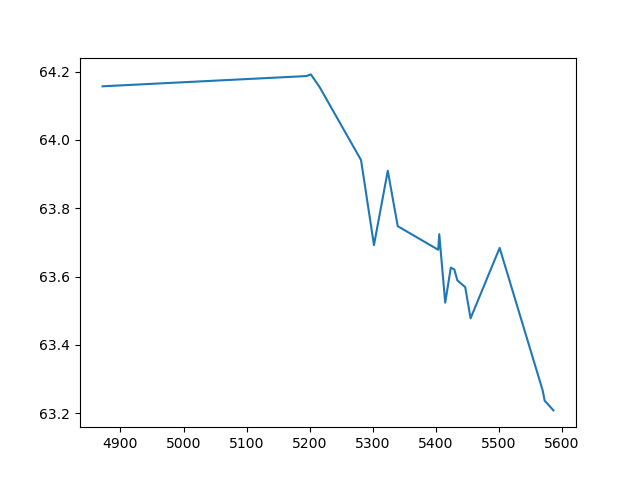

In [35]:
# Look at the RVs for each segment
# See how they're different?
plt.figure()
plt.plot(sme.WRAN[:,0], sme.RV)

Now let's set the elements for which we want nlte calculations
- NLTE elements can be set or removed at any point using the syntax `sme.nlte.set_nlte(elem)` and `sme.nlte.remove_nlte(elem)`.
- The full list of NLTE capable elements and current default as well as deprecated grids can be found at https://pysme-astro.readthedocs.io/en/stable/concepts/nlte.html.

In [8]:
sme.nlte.set_nlte('Fe')

In [9]:
# Fix some known parameters for this example.
sme.logg = 4.48

In [ ]:
create_mcmc_grid(sme, {'teff': np.arange(5000,5500,100), 'monh': np.arange(-0.7,-0.2,0.1)}, delta_lambda=0.006, derived_params={'vmic':'galah'}, filename='teff_monh_galahvmic_grid', nprocesses=8, return_grid=False)

In [ ]:
create_mcmc_grid(sme, {'teff': np.arange(5000,5500,100), 'monh': np.arange(-0.7,-0.2,0.1), 'vmac': np.arange(0,7,1)}, delta_lambda=0.006, derived_params={'vmic':'galah'}, filename='teff_monh_vmac_galahvmic_grid', nprocesses=8, return_grid=False)

In [10]:
mcobj1 = MCMCsetup(sme, grids='teff_monh_galahvmic_grid.npz', vsini_grid=[0,7])
sampler1 = mcobj1.run_mcmc(nprocesses=8)

100%|██████████| 4500/4500 [01:49<00:00, 41.09it/s]


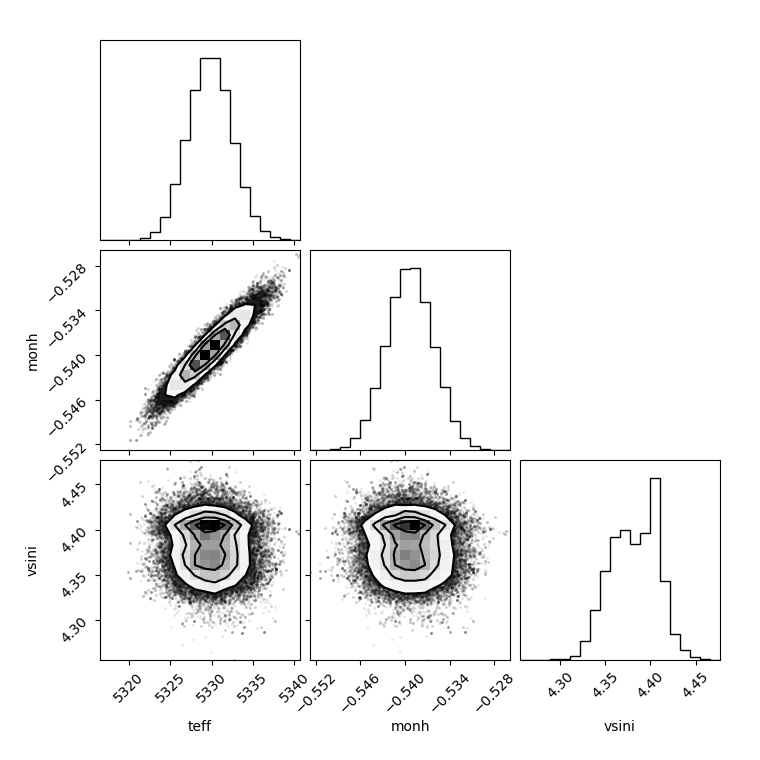

In [ ]:
samples = sampler1.get_chain(discard=750, thin=1, flat=True)
import corner
labels = ['teff', 'monh', 'vsini']
corner.corner(samples, labels=labels)
plt.show()

In [14]:
mcobj2 = MCMCsetup(sme, grids='teff_monh_vmac_galahvmic_grid.npz', vsini_grid=[0,7])
sampler2 = mcobj2.run_mcmc(nprocesses=8)

100%|██████████| 4500/4500 [03:33<00:00, 21.12it/s]


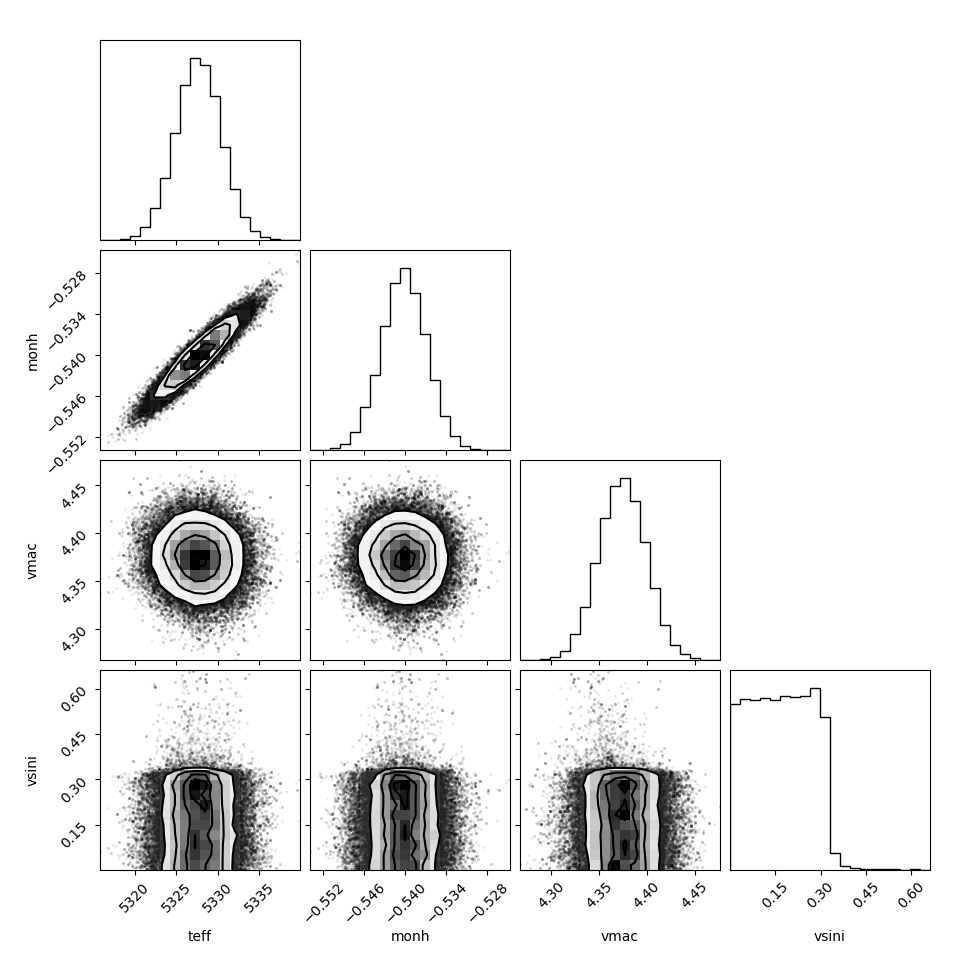

In [37]:
samples = sampler2.get_chain(discard=750, thin=1, flat=True)
import corner
labels = ['teff', 'monh', 'vmac', 'vsini']
corner.corner(samples, labels=labels)
plt.show()

In [40]:
samples.mean(0)

array([5327.650036,   -0.540243,    4.37413 ,    0.168811])